In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statstests.process import stepwise
from scipy.stats import shapiro #teste de Shapiro-Wilk
from scipy import stats #testes estatísticos
from statsmodels.stats.outliers_influence import variance_inflation_factor #diagnóstico de multicolinearidade
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler

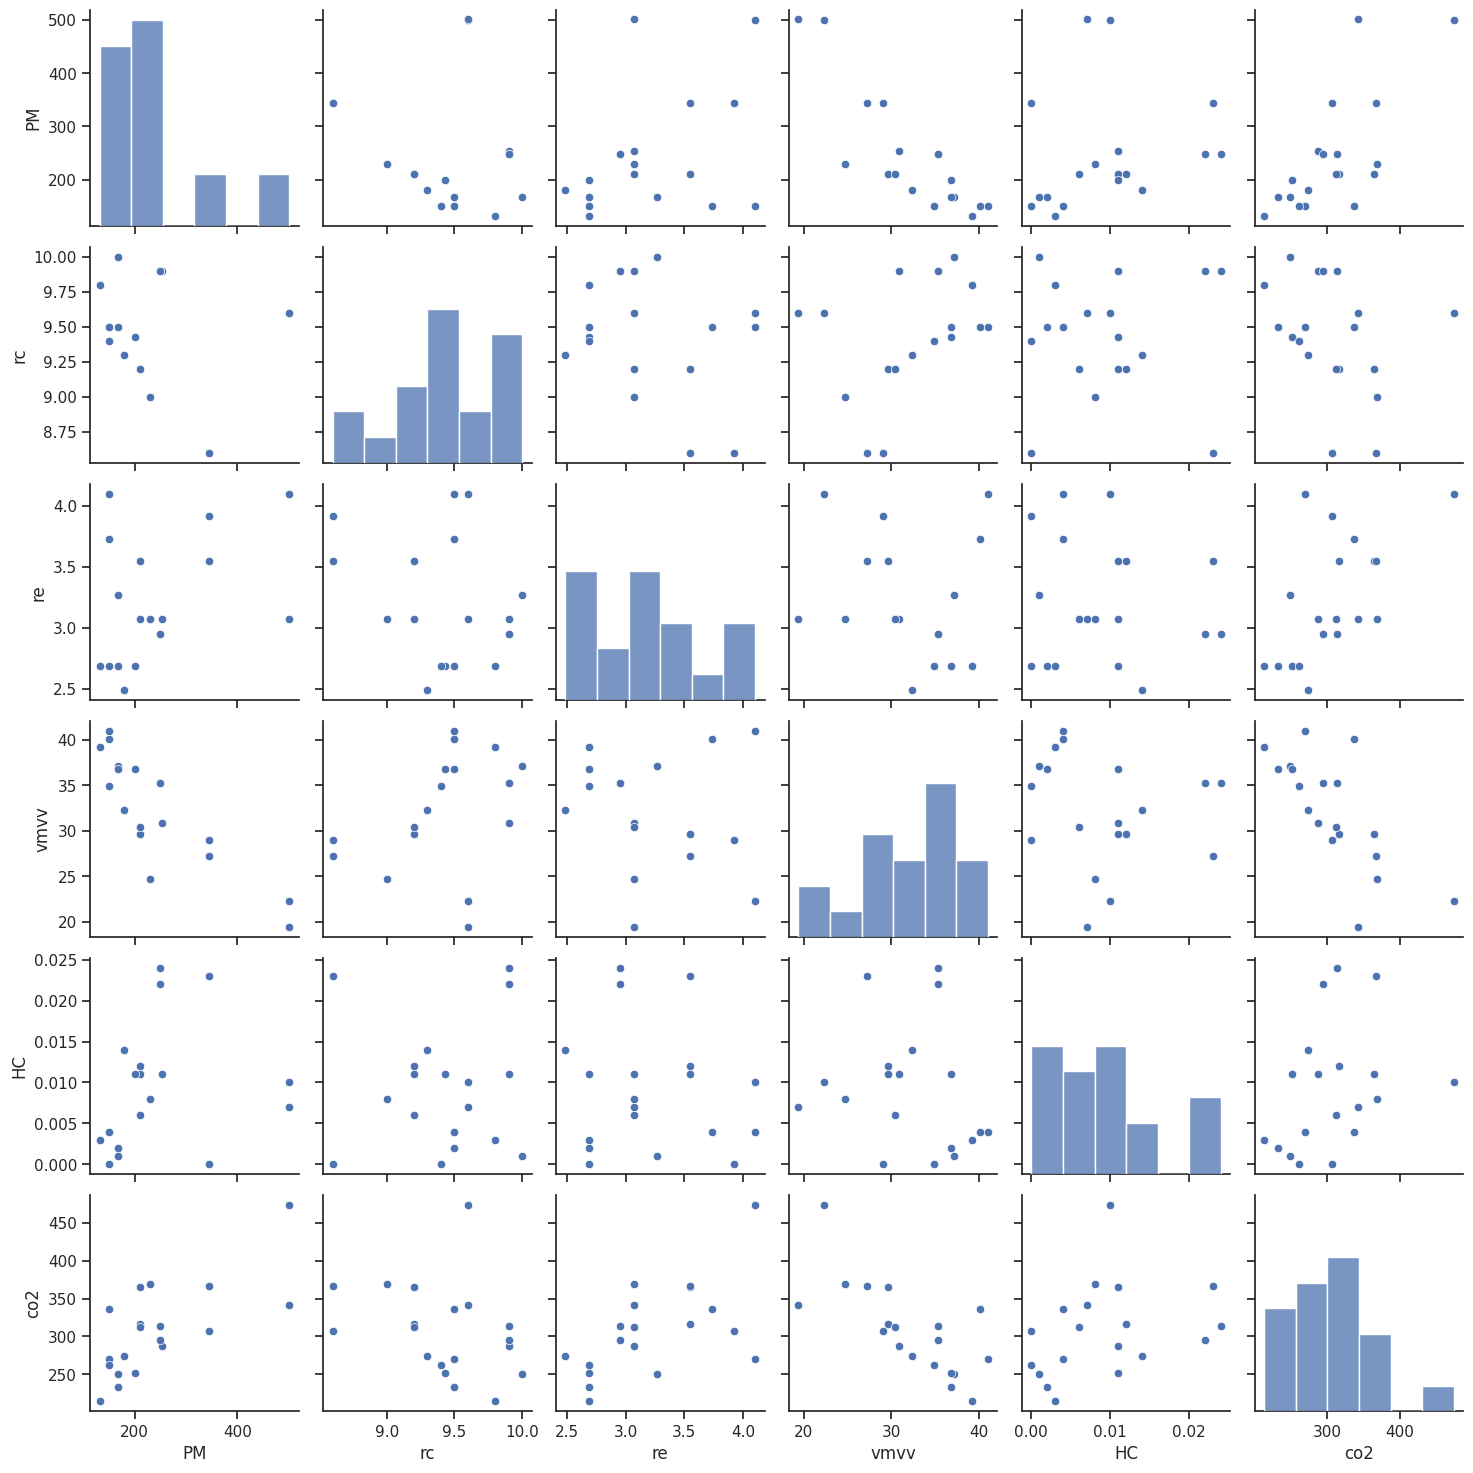

In [25]:
df = pd.read_excel('dataset.xlsx')  

#Retirando todas as linhas o com valor de mpg nulo
df = df.dropna(subset=['mpg'])

#substituir o valor do rc faltante pela média de suas váriaveis
rc_mean = df[df['rc'].notnull()]['rc'].mean()
df.loc[df['rc'].isnull(), 'rc'] = rc_mean

#Substituido um valor de co2 impossivel de ser feito
co2_mean = int(round(df[df['co2'] != 0]['co2'].mean()))
df.loc[df['co2'] == 0, 'co2'] = co2_mean

#Removendo a variavel que queremos medir
df.set_index('Modelo do carro', inplace=True)

# 2. SEGUNDO: Agora sim, remova a variável que queremos medir (ela já virá com os nomes dos carros!)
target = df['mpg']
df = df.drop(columns=['mpg'])

# Colunas nao importantes para a analise que serao removida
colunas_removidas = ['cfab','tipo','csd']
df = df.drop(columns = colunas_removidas)

# Verificando se as variaveis são correlacionadas

sns.set(style='ticks')
sns.pairplot(df)



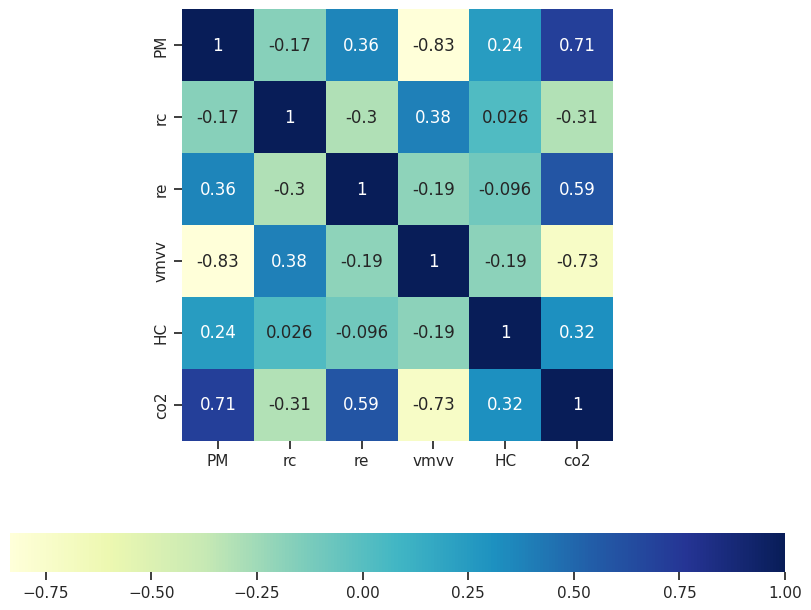

In [43]:
plt.figure(figsize=(10,8))
ax=sns.heatmap(df.corr(),
               annot=True,
               cmap='YlGnBu',
               cbar_kws={"orientation":"horizontal"})
ax.set_aspect("equal")

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

pca = PCA()
pca_result = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(
    pca_result, 
    columns=[f'CP{i+1}' for i in range(pca_result.shape[1])],
    index=df.index # Mantém os nomes dos carros nas linhas!
)

print("Dados prontos e transformados em Componentes Principais:")
print(df_pca.head())

Dados prontos e transformados em Componentes Principais:
                         CP1       CP2       CP3       CP4       CP5       CP6
Modelo do carro                                                               
300C/SRT-8         -0.391560  0.913423  0.624412 -0.501469 -0.057567 -0.377162
CARAVAN 2WD        -0.893655  0.975640 -1.294298  0.091591  0.178279  0.019568
CROSSFIRE ROADSTER -1.840722 -0.440638  1.189078 -0.651849 -0.032965 -0.266922
DAKOTA PICKUP 2WD   0.596386 -0.315465 -0.244788  0.640951  0.048575 -0.574359
DAKOTA PICKUP 4WD   1.011650 -0.392861 -0.066196  0.668944  0.650261 -0.209557


In [28]:
print("Explicação da variância por componente principal:")
eigenvalues = pca.explained_variance_
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

for i in range(len(eigenvalues)):
    print(f"PC{i+1}: Autovalor = {eigenvalues[i]:.3f}, Variância = {explained_variance[i]:.1%}, Acumulada = {cumulative_variance[i]:.1%}")


Explicação da variância por componente principal:
PC1: Autovalor = 3.161, Variância = 49.9%, Acumulada = 49.9%
PC2: Autovalor = 1.259, Variância = 19.9%, Acumulada = 69.8%
PC3: Autovalor = 0.847, Variância = 13.4%, Acumulada = 83.2%
PC4: Autovalor = 0.779, Variância = 12.3%, Acumulada = 95.5%
PC5: Autovalor = 0.221, Variância = 3.5%, Acumulada = 99.0%
PC6: Autovalor = 0.066, Variância = 1.0%, Acumulada = 100.0%


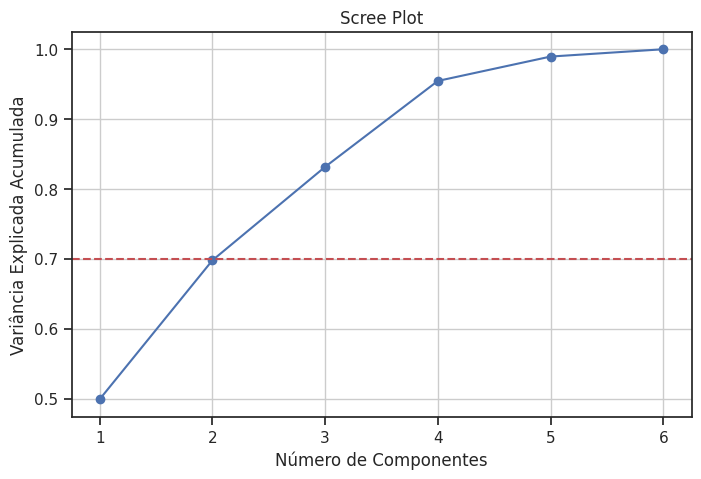

In [29]:
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(8,5))

plt.plot(range(1, len(cumulative)+1),
         cumulative,
         marker='o')

plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Scree Plot')

plt.axhline(y=0.70, color='r', linestyle='--')
plt.grid(True)

plt.show()

In [30]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'CP{i+1}' for i in range(pca.n_components_)],
    index=df.columns
)

components = loadings.iloc[:, :3]

print(np.round(loadings.iloc[:, :3], 3))

        CP1    CP2    CP3
PM    0.503  0.176  0.135
rc   -0.270  0.443  0.766
re    0.330 -0.512  0.532
vmvv -0.504 -0.132  0.253
HC    0.174  0.702 -0.089
co2   0.530  0.023  0.201


In [31]:
for component in components.columns:
    print(f"Componente {component}:")
    sorted_loadings = components[component].abs().sort_values(ascending=False)
    for variable in sorted_loadings.index:
        loading_value = components.loc[variable, component]
        if abs(loading_value) > 0.3:  # Considerando apenas loadings significativos
            print(f"  {variable}: {loading_value:.3f}")

Componente CP1:
  co2: 0.530
  vmvv: -0.504
  PM: 0.503
  re: 0.330
Componente CP2:
  HC: 0.702
  re: -0.512
  rc: 0.443
Componente CP3:
  rc: 0.766
  re: 0.532


In [32]:
# 1. Criamos um DataFrame apenas com os 3 componentes que importam
df_final = df_pca[['CP1', 'CP2', 'CP3']].copy()

# 2. Colamos a nossa variável alvo de volta na tabela
df_final['mpg'] = target

# 3. Calculamos a correlação de tudo contra o mpg
matriz_correlacao = df_final.corr()

print("Correlação dos Componentes com o Consumo (MPG):")
print(matriz_correlacao[['mpg']].sort_values(by='mpg', ascending=True))

Correlação dos Componentes com o Consumo (MPG):
          mpg
CP1 -0.916298
CP3 -0.037391
CP2  0.130869
mpg  1.000000


In [33]:
print("Top 5 Carros Menos Econômicos:")
display(df_final[['CP1', 'mpg']].sort_values(by='CP1', ascending=False).head())

# Ver os 5 carros MAIS ECONÔMICOS (Menor CP1 = Maior MPG)
print("\nTop 5 Carros Mais Econômicos:")
display(df_final[['CP1', 'mpg']].sort_values(by='CP1', ascending=True).head())

Top 5 Carros Menos Econômicos:


,CP1,mpg
Modelo do carro,,
RAM 1500 PICKUP 2WD,4.069566,18.7
DURANGO 2WD,2.576526,24.1
VIPER CONVERTIBLE,2.371700,25.9
RAM 1500 PICKUP 4WD,1.587121,20.3
GRAND CHEROKEE 4WD,1.304635,24.2



Top 5 Carros Mais Econômicos:


,CP1,mpg
Modelo do carro,,
NEON/SRT-4/SX 2.0,-2.722743,41.3
STRATUS 4-DR,-1.997304,37.9
CROSSFIRE ROADSTER,-1.840722,35.4
TOWN & COUNTRY 2WD,-1.634019,33.8
SEBRING 4-DR,-1.406016,35.1


In [ ]:
# 1. Lendo o arquivo original novamente apenas para pegar a coluna 'tipo'
df_original = pd.read_excel('dataset.xlsx')
df_original = df_original.dropna(subset=['mpg']) # Garantir que tem o mesmo tamanho
df_original.set_index('Modelo do carro', inplace=True)

# 2. Colando a coluna 'tipo' no nosso df_final
df_final['tipo'] = df_original['tipo']

# 3. (Opcional) Vamos renomear as siglas para deixar a legenda do gráfico mais bonita
df_final['Categoria'] = df_final['tipo'].map({'C': 'Passeio', 'T': 'Caminhonete'})

print(df_final.sort_values(by='mpg', ascending=False)) 

                           CP1       CP2       CP3   mpg tipo    Categoria
Modelo do carro                                                           
NEON/SRT-4/SX 2.0    -2.722743  0.014049  0.064907  41.3    C      Passeio
STRATUS 4-DR         -1.997304 -0.301018 -0.501814  37.9    C      Passeio
CROSSFIRE ROADSTER   -1.840722 -0.440638  1.189078  35.4    C      Passeio
SEBRING 4-DR         -1.406016  0.545248 -0.645906  35.1    C      Passeio
TOWN & COUNTRY 2WD   -1.634019 -0.580707 -0.677373  33.8    T  Caminhonete
LIBERTY/CHEROKEE 2WD -1.105028 -1.697115  1.295526  32.8    T  Caminhonete
CARAVAN 2WD          -0.893655  0.975640 -1.294298  32.5    T  Caminhonete
300C/SRT-8           -0.391560  0.913423  0.624412  30.8    C      Passeio
PACIFICA 2WD         -0.545201  1.994462  0.567436  30.0    T  Caminhonete
GRAND CHEROKEE 2WD    0.023889 -0.408084 -0.673805  28.5    T  Caminhonete
PACIFICA AWD         -0.327322  2.194064  0.607514  28.2    T  Caminhonete
DAKOTA PICKUP 2WD     0.5

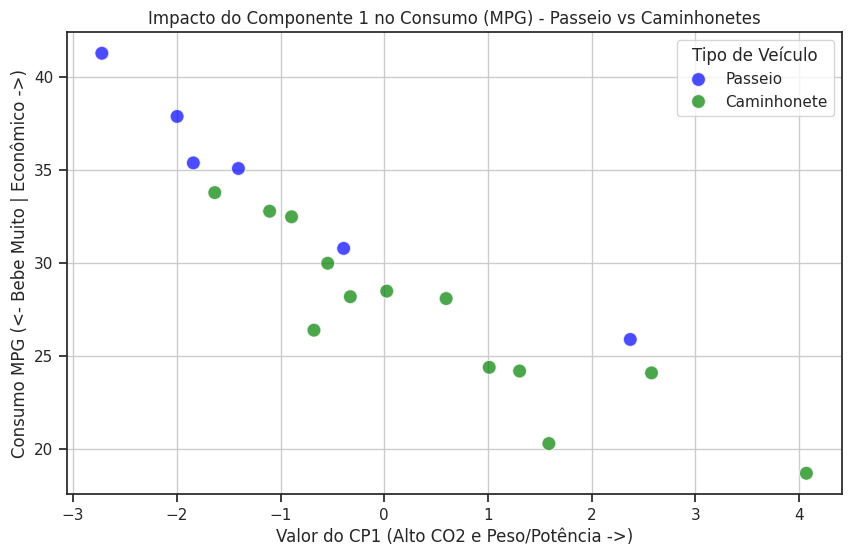

In [36]:
# Definindo as cores exatas que você pediu
# 'C' (Passeio) será azul, 'T' (Caminhonete) será verde
cores_personalizadas = {'Passeio': 'blue', 'Caminhonete': 'green'}

plt.figure(figsize=(10,6))

# Criando o gráfico
sns.scatterplot(
    data=df_final, 
    x='CP1', 
    y='mpg', 
    hue='Categoria',          # Aqui nós mandamos ele separar pelas categorias!
    palette=cores_personalizadas, # Aqui aplicamos o azul e verde
    s=100,                    # Tamanho dos pontos (deixa eles mais visíveis)
    alpha=0.7                 # Leve transparência para ver pontos sobrepostos
)

# Acabamento do gráfico
plt.title('Impacto do Componente 1 no Consumo (MPG) - Passeio vs Caminhonetes')
plt.xlabel('Valor do CP1 (Alto CO2 e Peso/Potência ->)')
plt.ylabel('Consumo MPG (<- Bebe Muito | Econômico ->)')
plt.grid(True)

# Ajustando a legenda
plt.legend(title='Tipo de Veículo', loc='upper right')

plt.show()

# Conclusão do Estudo de Consumo (MPG)
A análise de componentes principais combinada com a correlação revelou que o consumo de combustível dos veículos (mpg) é ditado quase exclusivamente por um único conjunto de características, enquanto outros fatores mecânicos são irrelevantes para a economia.

1. O que destrói a economia de combustível (CP1):

Existe uma correlação negativa fortíssima (-0.916) entre o Componente 1 e o mpg.

O que isso significa: Carros com altos valores de emissão de CO2 e alta Potência/Peso (PM) fazem o consumo do carro despencar (bebem muito).

A solução: A variável vmvv puxa o CP1 para baixo (sinal negativo na receita do componente). Portanto, para aumentar o mpg (ter um carro mais econômico), a engenharia deve focar em aumentar o vmvv e reduzir o PM e o CO2.

2. O que NÃO afeta o consumo de combustível (CP2 e CP3):

Os Componentes 2 e 3 possuem correlação quase zero com o mpg (0.13 e -0.03, respectivamente).

O que isso significa: Variáveis puramente mecânicas, como a Razão de Compressão (rc), ou emissões secundárias como Hidrocarbonetos (HC), não têm impacto significativo na economia de combustível.

A solução: Alterar a compressão do motor (rc) para buscar outras melhorias de performance pode ser feito livremente, pois os dados provam que isso não vai prejudicar (nem ajudar) o mpg do carro.

Além disso, observando o grafico do CP1 em relação a caminhonetes e carros de passeio, pode-se concluir que as caminhonetes tendem a ser menos economicas que carros de passeios.